<a href="https://colab.research.google.com/github/imaniiz/CariSurg-Portfolio/blob/feat%2Fweek-6-refactor/Notebooks/Week6_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CARISURG MedTech Pathways | Heathcare AI Programme | Week 6 Assignment
#**AI-Assisted Triage: Baseline Model Development**

---

##**About this Notebook**

This notebook builds upon the exploratory data anlysis and data quality assessment completed in Week 5 by delivered developing the first baseline machine learning model for AI-assisted emergency department triage. Using the cleaned Yale EMMLC dataset, the objective is to determine whether simple, interpretable models can predict Emergency Severity Index (ESI) levels better than a random baseline.The **primary clinical conern** is correctly identifying ESI level 1 patients, as these patients require immediate life-saving intervention.

##Baseline Classification Algorithms:
1. Logistic Regression
2. Decision Tree Classification  

The performance of the algorithms is evaluated using metrics such as accuracy, precision, recall and F1-score and compared against a stratified random classifier.

##Research Question:
Can simple, interpretable machine learning models accurately predict Emergency Severity Index levels and which evaluation metricbest relflects clinically safe triage performance?

##Notebook Sections

Section 1: Data Loading & Environment Setup

Section 2: Feature Selection & Target Variable

Section 3: Training/Test Split

Section 4: Stratified Baseline Random Classifier

Section 5: Model 1 - Logistic Regression

Section 6: Model 2 - Decision Tree  

Section 7: Model Predictions and Confusion Matrix

Section 8:  Model Evaluation - Accuracy, Precision, Recall & F1

Section 9: Model Comparison

Section 10: Conclusion & Failure Mode Reflection


---



##**Section 1: Data Loading and Environment Setup**

This section imports the Python libraries required to prepare the data, build the baseline classifiers and evaluate their performance.

- Pandas - Used to load and organise the dataset in tabular form
- NumPy - Supports numerical operations and reproducibility settings
- Matplotlib - Used to create visualisations
- Scikit-learn - Provides the tools used to create the required 80/20 train-test split and train the classifiers
- DummyClassifiers - Used to create a stratified random baseline agaisnt which the trained models can be compared

A fixed random seed of 42 is used wherever an operation includes randomness.

In [31]:
# Importing relevant python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

pd.set_option("display.width", 120)
print("Libraries loaded ✅")

Libraries loaded ✅


In [32]:
# Environment setup
# Reloading cleaned triage dataset from week 5
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

CLEAN_PATH = Path('/content/drive/MyDrive/Carisurg Portfolio/CariSurg_Week5/triage_cleaned_v1.csv')

df = pd.read_csv(CLEAN_PATH)

# Printing the shape and first five rows of the dataset
print(df.shape)
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(55121, 225)
Loaded 55121 patients and 225 columns.


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
##**Section 2: Feature Selection & Target Variable**

This section defines the target variable (**Y**) that models will predict and selects the patient characteristics available at the time of triage as input features (**X**). The target variable is **Emergency Severity Index (ESI)**, represented by the 'esi' column in the dataset.

The predictor variables used in this baseline model were identified furing the Week 5 exploratory analysis. Selection was based on a combination of association with ESI, clinical relevance to patient urgency and availabiltiy during the initial triage assessment. The model uses 208 variables available during triage, including vital-sign measurements, oxygen-device information and binary chief-complaint indicators. Demographic and administrative variables, including age and arrival mode, are excluded from this baseline. Post-triage outcome variables are also excluded to prevent data leakage.

Administrative and demographic variables are excluded from this baseline model. Variables recorded after triage, including patient disposition, are also excluded to prevent data leakage, where the mdoel uses information that would not have been available when the original triage decision was made.

In [33]:
# Target variable
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Demographic variables excluded from the baseline model
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# OUTCOMES of the visit — known only AFTER triage, so they are excluded from the baseline model
LEAKAGE = ["disposition", "previousdispo"]

# Selecting the permitted model features
FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

In [34]:
# Machine learning divides the dataset into two parts:

# X contains the clinical features the models will use as predictors
X = df[FEATURES]

# Y contains the correct ESI level the models will learn to predict
y = df[TARGET]

# Displaying the selected features and dimensions of X and Y
print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:6], "...")
print("Feature matrix shape", X.shape)
print("Target shape:", y.shape)

Model will use 208 features to predict: esi
First few features: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device'] ...
Feature matrix shape (55121, 208)
Target shape: (55121,)


---
##**Section 3: Training/Test Split**

The dataset is divded into training and testing sets before the models are developed. The models will learn from 80% of the patient encounters, while the remaining 20% will be kepy unseen for evaluation. The split is stratified by ESI level so that the proportion of each triage category remains similar in both sets. A fixed random seed of 42 makes the split reproducible.

In [35]:
# Separating a TEST set (20%) that the model will not see during training,
# so the model can be graded honsetly
# - test_size = keeps 20% for testing
# - stratify=y keeps the ESI mix balanced across both sets
# - random_state = (any fixed number) makes the split reproducible

# Splitting the dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Displaying the number of patients in each set
print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025



---
##**Section 4: Statified Baseline Random Classifier**

Before training the logistic regression and decision tree models, a stratified random classifier is created as a minimum performance benchmark. This classifier does not learn meaningful clinical relationships. Instead, it randomly predicts ESI levels according to their proportions in the training data.

The trained models should perform substantially better than this baseline to demonstrate that they have learned useful patterns from the patient information.

In [36]:
# Creating a classifier that makes stratified random predictions
dummy = DummyClassifier(strategy="stratified", random_state=42)

# Fitting the baseline classifier using the training data
dummy.fit(X_train, y_train)

# Calculating its accuracy on the unseen test set
dummy_accuracy = dummy.score(X_test, y_test)
print(f"Dummy classifier accuracy: {dummy_accuracy:.3f}")


Dummy classifier accuracy: 0.375


### **Clinical Question 1:**

If the train-test split is repeated using a different 'random_state', does the accuracy of the stratified random classifier change?

In [37]:
# Repeating the 80/20 split using a different random seed (10)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, test_size=0.2, stratify=y, random_state=100)

# Creating a classifier that makes stratified random predictions
dummy_2 = DummyClassifier(strategy="stratified", random_state=100)

# Fitting the baseline classifier using the training data
dummy_2.fit(X_train_2, y_train_2)

# Calculating its accuracy on the unseen test set
dummy_2_accuracy = dummy_2.score(X_test_2, y_test_2)

print(f"Dummy classifier accuracy with random_state=42: {dummy_accuracy:.3f}")
print(f"Dummy classifier accuracy with random_state=100: {dummy_2_accuracy:.3f}")

Dummy classifier accuracy with random_state=42: 0.375
Dummy classifier accuracy with random_state=100: 0.372


###**Section 4 Observations**

The accuracy changed slightly when a different random seed was used from 0.375 to 0.372. Changing the seed assigns a different selection of patient encounters to the training and testing sets. Since the dummy classifier makes random predictions based on the ESI class distribution, small variations in its accuracy are expected. The original split created using 'random_state=42' will be retained for the remainder of the analysis so that all models are trained and evaluated using the same patient groups, allowing a fair comparison


---
##**Section 5: Model 1 - Logistic Regression**

Logistic regression is an interpretable classification model that estimates the probability of a patient belonging to each ESI level. It combines input features-such as vital signs and cheif-complain indicators into scores, converts them into probabilities and predicts the ESI level with the highest probability. The model creates linear boundaries between classes.

Before training the model, the input features are standardised so that variables measured on different scales can be compared fairly. The scaler is fitted only to the training data and then applied to the test data. This prevents information from the unseen test set from influencing model training.

In [38]:
# Creating the feature scaler
scaler = StandardScaler()

# Applying scaling to the training data and unseen test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and training the logistic regression model
logreg = LogisticRegression(max_iter=1000, random_state = 42)
logreg.fit(X_train_scaled, y_train)

# Calculating accuracy on the unseen test set
logreg_accuracy = logreg.score(X_test_scaled, y_test)
print(f"Logistic regression accuracy: {logreg_accuracy:.3f}")


Logistic regression accuracy: 0.667


###**Clinical Question 2:**

Does logistic regression predict ESI levels more accurately than the stratified random baseline?

In [39]:
# Compare logistic regression with the random baseline
print(f"Stratified random baseline accuracy: {dummy_accuracy:.3f}")
print(f"Logistic regression accuracy: {logreg_accuracy:.3f}")
print(f"Logistic Regression improvement over baseline: {logreg_accuracy - dummy_accuracy:.3f}")


Stratified random baseline accuracy: 0.375
Logistic regression accuracy: 0.667
Logistic Regression improvement over baseline: 0.291


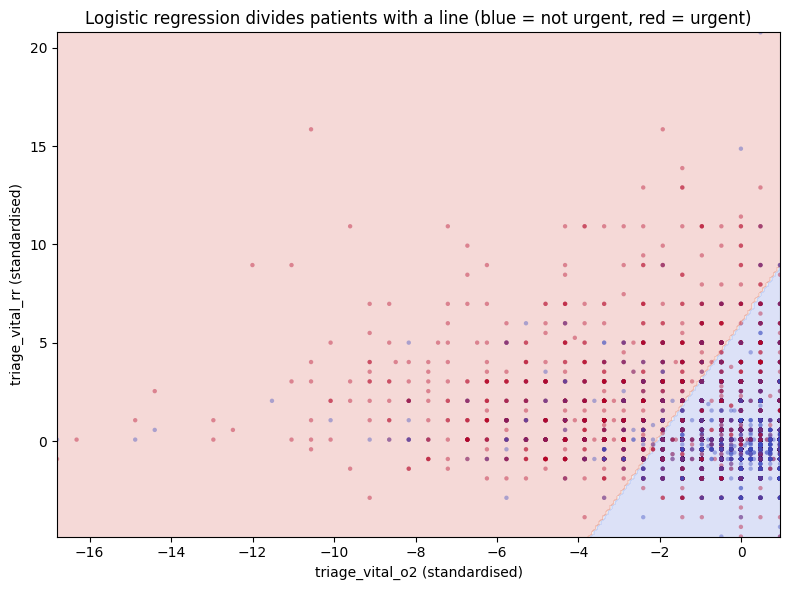

In [40]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1) Selecting two vital signs for the visualisation
f1, f2 = "triage_vital_o2", "triage_vital_rr"

# 2) Making a two-class label: urgent (ESI 1-2) vs not urgent (ESI 3-5)
urgent = (y <= 2).astype(int)          # 1 = urgent, 0 = not urgent

# 3) Scaling the two selected features
two = StandardScaler().fit_transform(X[[f1, f2]])

# 4) train a small logistic regression on just those two features
demo = LogisticRegression(max_iter=1000).fit(two, urgent)

# 5) Creating a grid of points and ask the model to classify each, so we can shade the two "decision regions"
xx, yy = np.meshgrid(np.linspace(two[:, 0].min(), two[:, 0].max(), 200),
                     np.linspace(two[:, 1].min(), two[:, 1].max(), 200))

zz = demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plotting the decision regions and patient observations
fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")                 # the two decision regions
ax.scatter(two[:, 0], two[:, 1], c=urgent, cmap="coolwarm",
           s=10, alpha=0.4, edgecolor="none")                      # the patients

ax.set_xlabel(f1 + " (standardised)")
ax.set_ylabel(f2 + " (standardised)")
ax.set_title("Logistic regression divides patients with a line (blue = not urgent, red = urgent)")
plt.tight_layout()
plt.show()

### **Clinical Question 3:**

In the initial logistic-regression visualisation, which corner of the plot is classified as urgent? When two different vital signs are used, does the dividing line separate urgent and non-urgent patients better or worse?


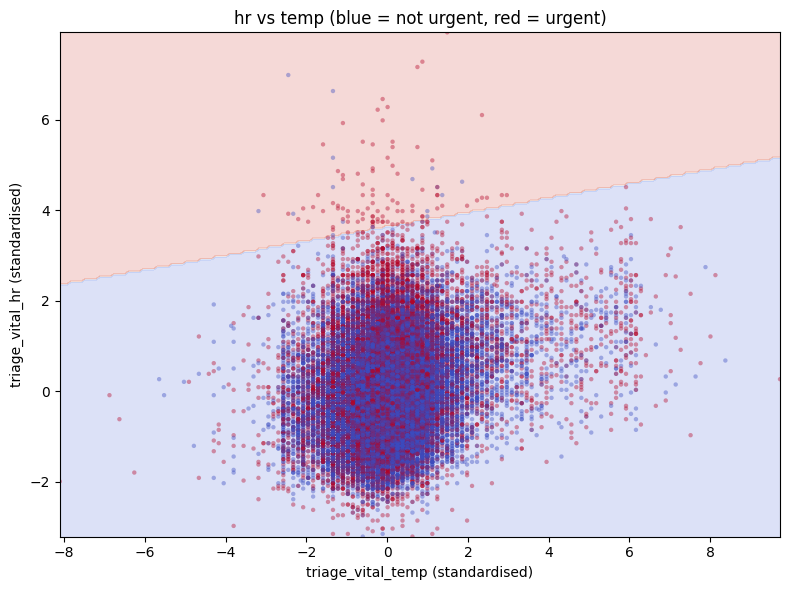

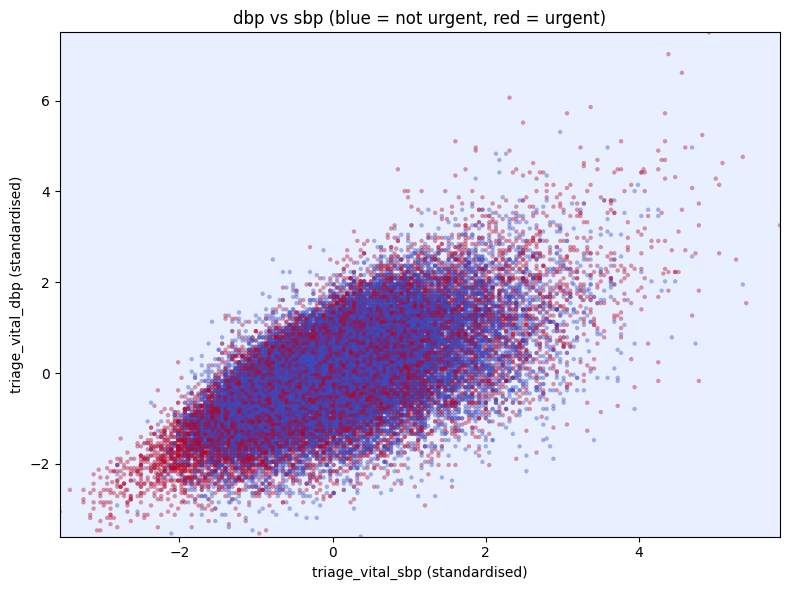

In [41]:
# Redoing plot using temperature and heart rate
f1, f2 = "triage_vital_temp", "triage_vital_hr"
urgent = (y <= 2).astype(int)
two = StandardScaler().fit_transform(X[[f1, f2]])
demo = LogisticRegression(max_iter=1000).fit(two, urgent)

xx, yy = np.meshgrid(np.linspace(two[:, 0].min(), two[:, 0].max(), 200),
                     np.linspace(two[:, 1].min(), two[:, 1].max(), 200))
zz = demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")
ax.scatter(two[:, 0], two[:, 1], c=urgent, cmap="coolwarm",
           s=10, alpha=0.4, edgecolor="none")
ax.set_xlabel(f1 + " (standardised)")
ax.set_ylabel(f2 + " (standardised)")
ax.set_title("hr vs temp (blue = not urgent, red = urgent)")
plt.tight_layout()
plt.show()

# Redoing plot using two other systolic and diastolic blood pressure
f1, f2 = "triage_vital_sbp", "triage_vital_dbp"
urgent = (y <= 2).astype(int)
two = StandardScaler().fit_transform(X[[f1, f2]])
demo = LogisticRegression(max_iter=1000).fit(two, urgent)

xx, yy = np.meshgrid(np.linspace(two[:, 0].min(), two[:, 0].max(), 200),
                     np.linspace(two[:, 1].min(), two[:, 1].max(), 200))
zz = demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")                 # the two decision regions
ax.scatter(two[:, 0], two[:, 1], c=urgent, cmap="coolwarm",
           s=10, alpha=0.4, edgecolor="none")                      # the patients

ax.set_xlabel(f1 + " (standardised)")
ax.set_ylabel(f2 + " (standardised)")
ax.set_title("dbp vs sbp (blue = not urgent, red = urgent)")
plt.tight_layout()
plt.show()


###**Section 5 Observations**

Logistic regression achieved an accuracy of 0.667, compared 0.375 for the stratified random baseline. This represents an improvement of 0.291, indicating that logistic regression learned useful relationships between the selected patient features and ESI level rather than merely reproducing random predictions. However, accuracy alone does not show how well the model identified each ESI level and further evaluation is required.

In the initial oxygen saturation-respiratory rate plot, the upper left area is classified as urgent which represents patients with lower oxygen saturation and higher respiratory rates. The lower - right region is classified as non-urgent, although the patient points overlap considerably. When temperature and heart rate were used, the model produced a small urgent region but still showed substantial overlap. When systolic and diastolic blood pressure were used, the separation became worse because the entire plotted region was classified as non-urgent and no dividing line was visible.

Overall, oxygen saturation and respiratory rate produced the clearest separation of the three pairs, although no pair reliably separated all urgent and non-urgent patients.


---

##**Section 6: Model 2 - Decision Tree**

A decision tree predicts ESI level by dividing patients into groups by using a series of feature-based rules. Unlike logistic regression, it does not require feature scaling. The tree is limited to a maximum depth of five. This keeps the model reasonably interpretable and reduces the risk of overfitting, where the tree learns overly specific patterns from the training data that do not generalise to new patients.

In [42]:
# Creating a decision tree classfier
# No scaling required
# max_depth=5 keeps the tree shallow -> easier to explain, less overfitting.
tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# Fitting the classifier on the unscaled X_train and y_train
tree.fit(X_train, y_train)

# Calculating the test accuracy of the decision tree
tree_test_accuracy = tree.score(X_test, y_test)
tree_train_accuracy = tree.score(X_train, y_train)
print(f"Decision Tree Test Set Accuracy: {tree_test_accuracy:.3f}")
print(f"Decision Tree Train Set Accuracy: {tree_train_accuracy:.3f}")


Decision Tree Test Set Accuracy: 0.556
Decision Tree Train Set Accuracy: 0.561


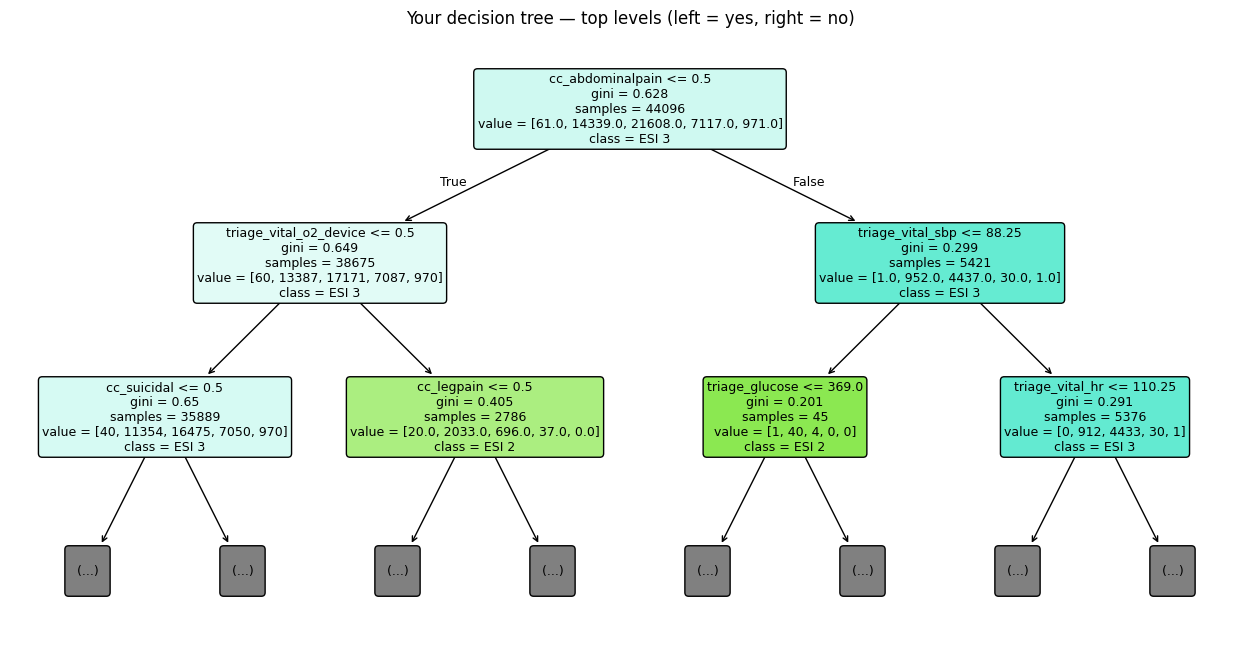

In [43]:
# Drawing the trained decision tree as a flow chart
# Initially, only the top two levels of the decision tree is shown with max_depth=2
from sklearn.tree import plot_tree
import os

os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    tree,                                             # trained section 6 tree
    feature_names=FEATURES,                           # shows real column names on each split
    class_names=[f"ESI {c}" for c in tree.classes_],  # labes each leaf with its ESI level
    filled=True,      # colour each box by the ESI level it predicts
    rounded=True,
    max_depth=2,      # only draws top 2 levels of the tree
    fontsize=9,
    ax=ax,
)
ax.set_title("Your decision tree — top levels (left = yes, right = no)")
plt.savefig("figs/w6_decision_tree.png", dpi=120, bbox_inches="tight")
plt.show()

In [44]:
# Printing the decision tree as plain text
# shows the exact numbers the tree splits on.
# |--- means one step deeper; "class:" lines are the predicted ESI level.
from sklearn.tree import export_text
print(export_text(tree, feature_names=list(FEATURES), max_depth=3))

|--- cc_abdominalpain <= 0.50
|   |--- triage_vital_o2_device <= 0.50
|   |   |--- cc_suicidal <= 0.50
|   |   |   |--- cc_alcoholintoxication <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_alcoholintoxication >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cc_suicidal >  0.50
|   |   |   |--- cc_nausea <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_nausea >  0.50
|   |   |   |   |--- class: 3
|   |--- triage_vital_o2_device >  0.50
|   |   |--- cc_legpain <= 0.50
|   |   |   |--- cc_chestpain <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_chestpain >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cc_legpain >  0.50
|   |   |   |--- cc_breathingdifficulty <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_breathingdifficulty >  0.50
|   |   |   |   |--- class: 2
|--- cc_abdominalpain >  0.50
|   |--- triage_vital_sbp <= 88.25
|  

###**Clinical Question 4:**

What is the first feature the tree splits on and why might that be clinically sensible for triage?

The decision tree first splits on ***cc_abdominal pain***, separating patients who reported abdominal pain from those who did not. This is clinically sensible because abdominal pain can indicate conditions ranging from minor illness to serious emergencies and often requires further assessment, laboratory tests or imaging. However, this does not prove it is the most clinically important feature; it was selected because it produced the greates reduction in class impurity at the point in the tree.

###**Clinical Question 5:**

How does changing the decision tree's maximum depth from 3 to 12 affect its training accuracy, test accuracy and interpretability?

In [45]:
# Creating a decision tree classifier with a max_depth of 3
tree_3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_3.fit(X_train, y_train)

# Printing original Decision Tree accuracy with maxdepth=3
print("Max Depth 3:")
print(f"Test Set Accuracy: {tree_test_accuracy:.3f}")
print(f"Train Set Accuracy: {tree_train_accuracy:.3f}")

# Creating a decision tree classfier with a max_depth of 12
tree_12 = DecisionTreeClassifier(max_depth=12, random_state=42)
tree_12.fit(X_train, y_train)

# Calculating the accuracies of the decision tree with max_depth=12
tree_12_test_accuracy = tree_12.score(X_test, y_test)
tree_12_train_accuracy = tree_12.score(X_train, y_train)
print("\nMax Depth 12:")
print(f"Test Set Accuracy: {tree_12_test_accuracy:.3f}")
print(f"Train Set Accuracy: {tree_12_train_accuracy:.3f}")


Max Depth 3:
Test Set Accuracy: 0.556
Train Set Accuracy: 0.561

Max Depth 12:
Test Set Accuracy: 0.584
Train Set Accuracy: 0.604


In [46]:
#Saving model and scaler to files for reuse
joblib.dump(logreg, "model_logreg.joblib")
joblib.dump(tree,   "model_tree.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅")

Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅


###**Section 6 Observations**

Increasing the decision tree's maximum depth from 3 to 12 increased training accuracy from 0.561 to 0.604 and test accuracy from 0.556 to 0.584. The deeper tree therefore performed better on both datasets because it could learn more detailed patterns.

However, the difference between training and test accuracy increased from 0.008 at depth 3 to 0.023 at depth 12. This suggests a greater risk of overfitting, although the depth 12 tree contained considerably more branches and was harder to interpret. This demonstrates the trade-off between predictive performance and interpretability.

*Why did we scale for logistic regression and not decision trees?*

The data was scaled for logistic regression because its coefficients and regularisation can be affected by features measured on different scales. Decision trees do not require scaling because they divide patients using feature thresholds. Scaling changes the numerical values of these thresholds but does not change the order of the patients, so it does not meaningfully affect the tree's decisions.

---
##**Section 7: Model Predictions & Confusion Matrix**

This section generates predicted ESI levels for the logistic-regression and decision-tree models using the unseen test data. Confusion matrices are then used to compare the predicted and actual ESI levels and identify which levels each model confuses most often.

In [47]:
# Getting each model's predicted ESI for the test set.

pred_logreg = logreg.predict(X_test_scaled)   # scaled features for LR
pred_tree   = tree.predict(X_test)            # unscaled for the tree
print("Example predictions (logreg):", pred_logreg[:10])

Example predictions (logreg): [2 3 3 2 2 2 3 3 3 2]


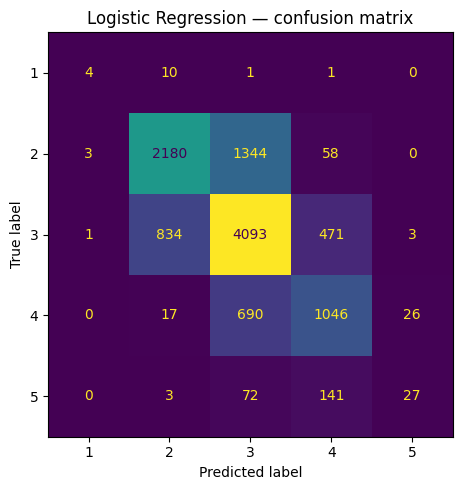

Saved figs/w6_confusion_logreg.png ✅


In [48]:
# Drawing the confusion matrix for logistic regression.
# Rows = true ESI, columns = predicted ESI. Diagonal = correct
# Saving the confusion matrix to figs/

import os
os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False)
ax.set_title("Logistic Regression — confusion matrix")
plt.tight_layout()
plt.savefig("figs/w6_confusion_logreg.png", dpi=110)
plt.show()
print("Saved figs/w6_confusion_logreg.png ✅")

###**Clinical Question 6:**

Which ESI levels does the decision-tree model confuse most frequently and what could be the clinical implications of these errors?

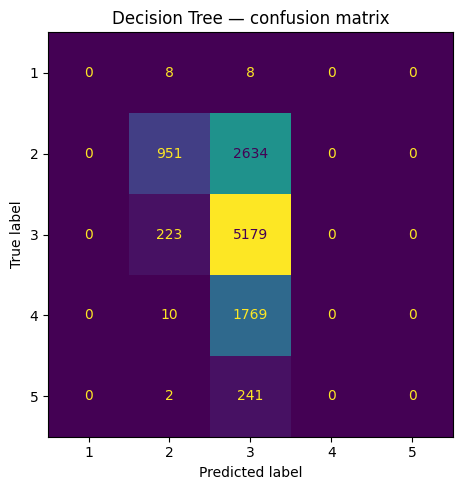

Saved figs/w6_confusion_tree.png ✅


In [49]:
# Drawing the confusion matrix for the decision tree
# Rows = actual ESI level; columns = predicted ESI level
# Diagonal values = correct predictions

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, ax=ax, colorbar=False)
ax.set_title("Decision Tree — confusion matrix")
plt.tight_layout()
plt.savefig("figs/w6_confusion_tree.png", dpi=110)
plt.show()
print("Saved figs/w6_confusion_tree.png ✅")


###**Section 7 Observations**

The confusion matrices show that the models performed very differently across the five ESI levels. Values on the diagonal represent correct predictions, while values outside the diagonal represent misclassifications.

The decision tree most frequently confused patients who were actually ESI Level 2 with ESI Level 3, affecting 2,634 patients. This represents under-triage because Level 2 patients are more urgent and should receive faster assessment than Level 3 patients. The tree also classified 1,769 Level 4 patients as Level 3, which represents over-triage and could result in unnecessary prioritisation and resource use. The decision tree also only predicted ESI Levels 2 and 3. It did not correctly classify any patients belonging to Level 1,4 or 5.

The logistic-regression model produced predictions across all five ESI levels and showed better separation between neighbouring categories. Its most frequent error was also confusing Level 2 with Level 3, affecting 1,344 patients.

Overall, logistic regression produced a more balanced confusion matrix. However, both models struggled with the rare ESI levels 1 and 5. This demonstrates why overall accuracy alone is insufficient: a model can correctly classify many common Level 3 patients while performing poorly on the rarer categories with important clinical consequences.

---
##**Section 8: Model Evaluation - Accuracy, Precision, Recall & F1**

This section evaluates the logistic regression model and decision tree using accuracy, precision, recall and F1 score for each ESI level. Macro and weighted F1 scores are compared to examine how class imbalance affects the overall evaluation. For each evaluation metric, a higher value indicates better performance.

| Metric | Meaning for ESI Evaluation |
|---|---|
| **Accuracy** | Percentage of all patients whose ESI level was predicted correctly.<br>May hide poor performance on rare levels. |
| **Precision** | Among patients predicted as a specific ESI level, the percentage who actually <br> belonged to that level. |
| **Recall** | Of the patients who actually belonged to an ESI level, the percentage<br>correctly identified. Especially important for identifying critical ESI Level 1 patients. |
| **Macro F1** | Average F1 across all five ESI levels, with each level weighted equally.<br>Useful for assessing performance on rare Levels 1 and 5. |
| **Weighted F1** | Average F1 weighted by the number of patients in each ESI level.<br>Influenced mainly by common Levels 2 and 3. |


###**Primary Metric: ESI Level 1 Recall**

Recall for ESI Level 1 was selected as the primary clinical metric because Level 1 represents patients requiring immediate life-saving intervention. Missing a genuinely Level 1 patient could result in under-triage, delayed resuscitation and potentially preventable harm. Accuracy is less suitable as the primary metric because the dataset is imbalanced and is dominated by Levels 2 and 3. A model could therefore achieve reasonable accuracy while failing to identify critically ill Level 1 patients. ESI Level 1 recall directly measures the proportion of these highest-urgency patients correctly identified.





In [50]:
# Printing precision / recall / F1 for EACH ESI level and both models
print("Logisitc Regression Classification Report")
print(
    classification_report(
        y_test,
        pred_logreg,
        digits=3,
        zero_division=0
    )
)

print("Decision Tree Classification Report")
print(
    classification_report(
        y_test,
        pred_tree,
        digits=3,
        zero_division=0
    )
)

Logisitc Regression Classification Report
              precision    recall  f1-score   support

           1      0.500     0.250     0.333        16
           2      0.716     0.608     0.658      3585
           3      0.660     0.758     0.706      5402
           4      0.609     0.588     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.594     0.463     0.495     11025
weighted avg      0.666     0.667     0.661     11025

Decision Tree Classification Report
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.796     0.265     0.398      3585
           3      0.527     0.959     0.680      5402
           4      0.000     0.000     0.000      1779
           5      0.000     0.000     0.000       243

    accuracy                          0.556     11025
   macro avg      0.265     0.245     0.216     11025

In [51]:
# Comparing the two ways of averaging F1.

# Method 1: Macro F1 = every ESI level counts equally
logreg_macro_f1 = f1_score(
    y_test,
    pred_logreg,
    average="macro"
)

# Method 2: Weighted F1 = big classes dominate
logreg_weighted_f1 = f1_score(
    y_test,
    pred_logreg,
    average="weighted"
)

print(f"Logistic Regression Macro F1: {logreg_macro_f1:.3f}")
print(f"Logistic Regression Weighted F1: {logreg_weighted_f1:.3f}")



Logistic Regression Macro F1: 0.495
Logistic Regression Weighted F1: 0.661


In [52]:
# Extracting recall for ESI level 1 for each model.
# the ESI-1 recall, so we take element [0].

# Calculating ESI Level 1 recall for logistic regression
logreg_esi1_recall = recall_score(
    y_test,
    pred_logreg,
    labels=[1],
    average=None
)[0]

# Calculating ESI Level 1 recall for the decision tree
tree_esi1_recall = recall_score(
    y_test,
    pred_tree,
    labels=[1],
    average=None
)[0]

# Displaying both results
print(f"Logistic Regression ESI Level 1 Recall: {logreg_esi1_recall:.3f}")
print(f"Decision Tree ESI Level 1 Recall: {tree_esi1_recall:.3f}")


Logistic Regression ESI Level 1 Recall: 0.250
Decision Tree ESI Level 1 Recall: 0.000


###**Section 8 Observations**

The logistic-regression model acheived an overall accuracy of 0.667, meaning it correctly classified approximately 66.7% of the test patients. Its weighted F1 score of 0.661 was considerably higher than its macro F1 score of 0.495. This difference indicates that the model performed better on the common ESI levels than on the rarer classes. Weighted F1 is influenced more heavily by large classes, particularly ESI Levels 2 and 3, wheras macro F1 gives every ESI level equal importance.

According to the classification report, the model performed best on ESI Level 3, acheiving an F1 score of 0.706. In contrast, performance was much weaker for the rare ESI levels 1 and 5. ESI level 5 had the lowest F1 score of 0.181 and a recall of only 0.111.

When comparing the recall of logistic regression and decision trees, it was observed that logistic regression scored acheived a higher score of 0.25 compared to 0.00 for decision trees. However, the logistic regression still performed poorly as it missed 75% of the actual Level 1 patients. This represents a significant clinical limitation because under-triaging these patients could delay immediate and potentially life-saving treatment.

---
##**Section 9: Model Comparison**

This section compares the dummy baseline, logistic-regression model and decision tree using accuracy, macro F1 and recall for ESI Level 1. ESI Level 1 is specifically used because correctly identifying patients requiring immediate intervention is a critical clinical priority.

In [54]:
# Collecting the key numbers into one small table to
# compare the dummy baseline, logistic regression, and the tree.

def summarise(name, preds):
    return {
        "model": name,
        "accuracy": round((preds == y_test).mean(), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro"), 3),
        "recall_ESI1": round(recall_score(y_test, preds, labels=[1], average=None)[0], 3),
    }

table = pd.DataFrame([
    summarise("Dummy (baseline)", dummy.predict(X_test)),
    summarise("Logistic Regression", pred_logreg),
    summarise("Decision Tree", tree.predict(X_test)),
])
table

,model,accuracy,macro_F1,recall_ESI1
0,Dummy (baseline),0.375,0.204,0.00
1,Logistic Regression,0.667,0.495,0.25
2,Decision Tree,0.556,0.216,0.00


###**Clinical Question 7:**

Why model should be trusted more for triage and why?

Of the three models, logistic regression should be trsuted more as the baseline traige model because it acheived the highest accuracy and macro F1 score. It was also the only model that correctly identified any ESI level 1 patients, detecting 25% of the critical cases acheiveing an ESI level 1 recall score of 0.25. However, logistic regression still missed 75% of ESI level 1 patients. Therefore, it should only be considered preliminary clinical decision-support.

###**Clinical Question 8:**

Why is accuracy alone not enough for ESI prediction?

Accuracy alone is insufficient because the ESI classes are imabalanced, with many more patients belonging to common levels such as ESI level 2 and 3 than to level 1. A model can acheive reasonable accuracy by correctly predicting the common classes while completely missing rare but critically ill patients. For example, the decision tree acheived an accuracy of 0.556, but its ESI level 1 recal score was 0.00. This means that it correctly classified more than half the patients while failing to identify the patients requiring the most urgent intervention. Macro F1 and class specific recall must therefore be considered alongside accuracy for a more holistic comparisom.

##**Section 10: Conclusion & Failure Mode Relflection**

This notebook evaluated logistic regression and a bounded-depth decision tree against a stratified random baseline for predicting the five ESI levels. Both trained models performed better overall than the random baseline, indicating that the triage features contain useful predictive information.

***Logistic regression*** was the strongest baseline model, achieving an accuracy of 0.667, macro F1 of 0.495 and ESI Level 1 recall of 0.250. It outperformed both the decision tree and stratified random baseline and is therefore recommended for further development.

The model performed worst proportionally on ESI Level 5, correctly identifying only 11.1% of these patients. However, its most clinically serious failure was missing 12 of the 16 ESI Level 1 patients. Misclassifying a Level 1 patient as less urgent could delay immediate assessment and life-saving treatment. Therefore, the model may not be suitable for independent clinical use and would require further optimisation, validation and continued clinician oversight.